In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np

In [15]:
df_total = pd.read_csv('../../result/magma_with_patched_lines.csv')
df_vul = df_total[df_total['vul_label'] == 1]
df_nonvul = df_total[df_total['vul_label'] == 0]
df_patch = df_total[df_total['vul_label'] == -1]
text_patch_vul = ""
text_patch_nonvul = ""
for groupname, group in df_total.groupby("cntx_len"):
    group_vul = group[group['vul_label'] == 1]
    group_nonvul = group[group['vul_label'] == 0]
    group_patch = group[group['vul_label'] == -1]
    group_patch["vul_label"] = 0
    patch_vul = pd.concat([group_patch, group_vul], axis=0)
    group_patch["vul_label"] = 1
    patch_nonvul = pd.concat([group_patch, group_nonvul], axis=0)
    print(f"Context Size: {groupname}")
    print(f"\tROC-AUC (patch vs. vul): {sklearn.metrics.roc_auc_score(patch_vul['vul_label'], patch_vul['new_score'])}")
    print(f"\tROC-AUC (patch vs. non-vul): {sklearn.metrics.roc_auc_score(patch_nonvul['vul_label'], patch_nonvul['new_score'])}")
    text_patch_vul += f" {sklearn.metrics.roc_auc_score(patch_vul['vul_label'], patch_vul['new_score'])*100:.1f}\% &"
    text_patch_nonvul += f" {sklearn.metrics.roc_auc_score(patch_nonvul['vul_label'], patch_nonvul['new_score'])*100:.1f}\% &"
print(text_patch_vul)
print(text_patch_nonvul)

Context Size: 1
	ROC-AUC (patch vs. vul): 0.5265359419263457
	ROC-AUC (patch vs. non-vul): 0.5376128718130311
Context Size: 5
	ROC-AUC (patch vs. vul): 0.5241678470254958
	ROC-AUC (patch vs. non-vul): 0.55452151203966
Context Size: 10
	ROC-AUC (patch vs. vul): 0.5203943873937678
	ROC-AUC (patch vs. non-vul): 0.549431214589235
Context Size: 20
	ROC-AUC (patch vs. vul): 0.5464876947592068
	ROC-AUC (patch vs. non-vul): 0.5570777266288952
Context Size: 30
	ROC-AUC (patch vs. vul): 0.5465098264872521
	ROC-AUC (patch vs. non-vul): 0.5603532223796034
Context Size: 50
	ROC-AUC (patch vs. vul): 0.5515890580736544
	ROC-AUC (patch vs. non-vul): 0.5542116678470255
Context Size: 100
	ROC-AUC (patch vs. vul): 0.5404789305949008
	ROC-AUC (patch vs. non-vul): 0.5362075070821529
Context Size: 150
	ROC-AUC (patch vs. vul): 0.5554953080736543
	ROC-AUC (patch vs. non-vul): 0.5578412712464589
Context Size: 200
	ROC-AUC (patch vs. vul): 0.5534702549575071
	ROC-AUC (patch vs. non-vul): 0.5505488668555241
Con

/tmp/ipykernel_442208/3703228637.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_patch["vul_label"] = 0
/tmp/ipykernel_442208/3703228637.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_patch["vul_label"] = 1
/tmp/ipykernel_442208/3703228637.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

/tmp/ipykernel_442208/4086614723.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0][0].set_xticklabels(xticks)
/tmp/ipykernel_442208/4086614723.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0][1].set_xticklabels(xticks)


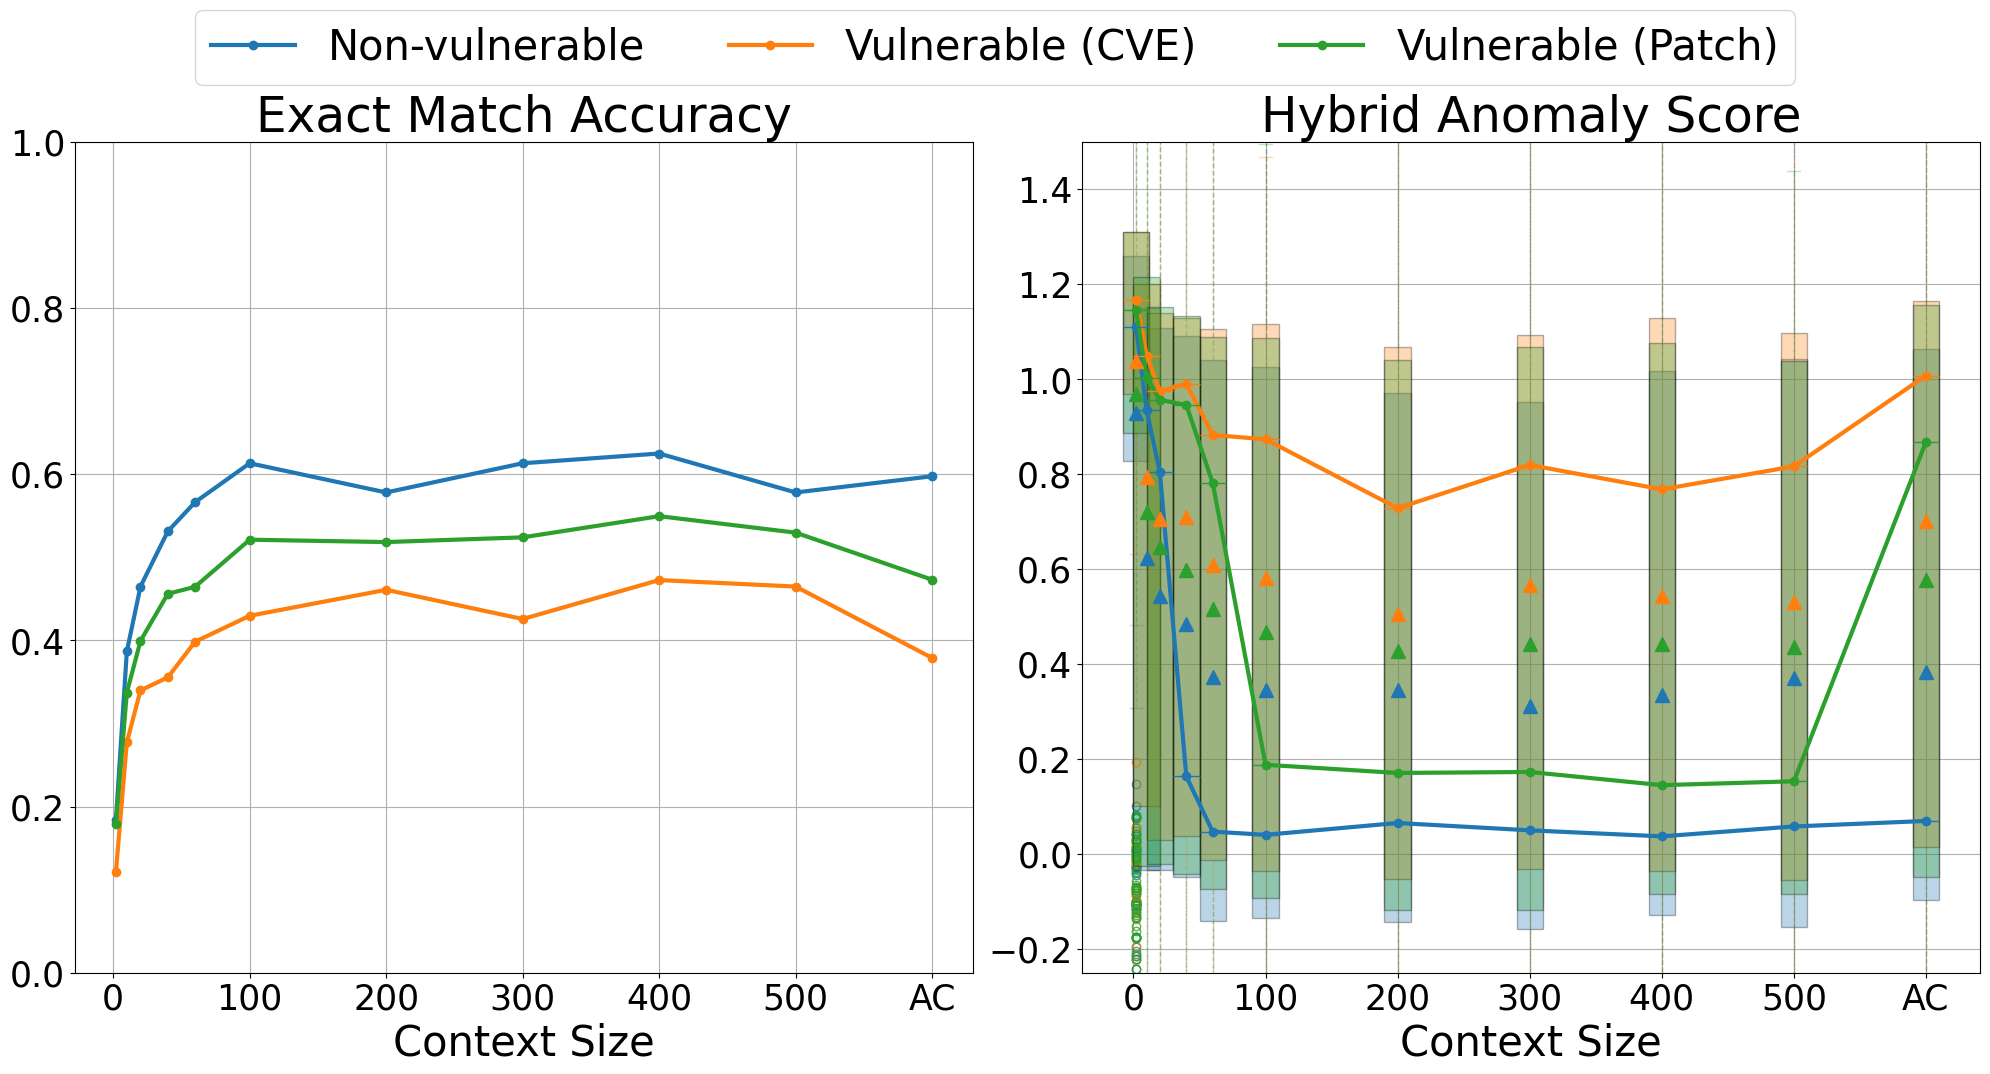

In [16]:
fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(4, 8)

df_vul = df_total[df_total.vul_label == 1]
df_nonvul = df_total[df_total.vul_label == 0]
axes = [[None, None, None], [None, None]]

# Plotting the EM accuracy distribution
axes[0][0] = plt.subplot(gs[0:4, 0:4])
axes[0][0].tick_params(axis='both', which='major', labelsize=25)
axes[0][0].plot((df_nonvul.groupby('cntx_len').exact_match.mean().index * 2).to_list(), df_nonvul.groupby('cntx_len').exact_match.mean(), marker='o', label='Non-vulnerable', linewidth=3)
axes[0][0].plot((df_vul.groupby('cntx_len').exact_match.mean().index * 2).to_list(), df_vul.groupby('cntx_len').exact_match.mean(), marker='o', label='Vulnerable (CVE)', linewidth=3)
axes[0][0].plot((df_patch.groupby('cntx_len').exact_match.mean().index * 2).to_list(), df_patch.groupby('cntx_len').exact_match.mean(), marker='o', label='Vulnerable (Patch)', linewidth=3)
axes[0][0].set_ylim(0, 1)
axes[0][0].grid()
axes[0][0].xaxis.set_major_locator(ticker.MultipleLocator(100))
axes[0][0].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0][0].set_title("Exact Match Accuracy", fontsize=35)
axes[0][0].set_xlabel("Context Size", fontsize=30)
xticks = [str(int(i)) for i  in axes[0][0].get_xticks()]
xticks[-2] = "AC"
axes[0][0].set_xticklabels(xticks)

# Plotting the Anomaly Score distribution
axes[0][1] = plt.subplot(gs[0:4, 4:8])
axes[0][1].tick_params(axis='both', which='major', labelsize=25)
boxplot_new_score_nonvul = df_nonvul[['cntx_len', 'new_score']].groupby("cntx_len").new_score.apply(func=list)
bp = axes[0][1].boxplot(boxplot_new_score_nonvul, positions=(boxplot_new_score_nonvul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C0', alpha=0.3)
plt.setp(bp["whiskers"], color='C0', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C0', alpha=0.3)
plt.setp(bp["medians"], color='C0', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C0', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C0', markeredgecolor="C0", alpha=1, markersize=10)
boxplot_new_score_vul = df_vul[['cntx_len', 'new_score']].groupby("cntx_len").new_score.apply(func=list)
bp = axes[0][1].boxplot(boxplot_new_score_vul, positions=(boxplot_new_score_vul.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C1', alpha=0.3)
plt.setp(bp["whiskers"], color='C1', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C1', alpha=0.3)
plt.setp(bp["medians"], color='C1', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C1', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C1', markeredgecolor="C1", alpha=1, markersize=10)
boxplot_new_score_patch = df_patch[['cntx_len', 'new_score']].groupby("cntx_len").new_score.apply(func=list)
bp = axes[0][1].boxplot(boxplot_new_score_patch, positions=(boxplot_new_score_patch.index * 2).to_list(), widths=20, patch_artist=True, showmeans=True)
plt.setp(bp["boxes"], facecolor='C2', alpha=0.3)
plt.setp(bp["whiskers"], color='C2', linestyle='--', alpha=0.3)
plt.setp(bp["caps"], color='C2', alpha=0.3)
plt.setp(bp["medians"], color='C2', alpha=1)
plt.setp(bp["fliers"], markeredgecolor='C2', alpha=0.8)
plt.setp(bp["means"], markerfacecolor='C2', markeredgecolor="C2", alpha=1, markersize=10)
axes[0][1].plot((boxplot_new_score_nonvul.index * 2).to_list(), np.median(np.vstack(boxplot_new_score_nonvul.to_numpy()), axis=1), marker='o', label='Non-vulnerable', linewidth=3)
axes[0][1].plot((boxplot_new_score_vul.index * 2).to_list(), np.median(np.vstack(boxplot_new_score_vul.to_numpy()), axis=1), marker='o', label='Vulnerable (CVE)', linewidth=3)
axes[0][1].plot((boxplot_new_score_patch.index * 2).to_list(), np.median(np.vstack(boxplot_new_score_patch.to_numpy()), axis=1), marker='o', label='Vulnerable (Patch)', linewidth=3)
axes[0][1].set_ylim(-0.25, 1.5)
axes[0][1].grid()
axes[0][1].xaxis.set_major_locator(ticker.MultipleLocator(100))
axes[0][1].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0][1].set_title("Hybrid Anomaly Score", fontsize=35)
axes[0][1].set_xlabel("Context Size", fontsize=30)
xticks = [str(int(i)) for i  in axes[0][1].get_xticks()]
xticks[-2] = "AC"
axes[0][1].set_xticklabels(xticks)

handles, labels = axes[0][1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', fontsize=30, ncol=3, bbox_to_anchor=(0.5, 1.09))
# fig.supxlabel('Anomaly Score', fontsize=35, x=-0.003)
plt.tight_layout()
plt.show()